<a href="https://colab.research.google.com/github/yana-g/graph-analysis/blob/main/05_Link_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stage 5: Link Prediction

This notebook builds and evaluates machine-learning models for predicting future collaborations between Israeli actors.

A strictly temporal design is used to prevent future information from leaking into model selection:

- **Training snapshot:** graph from 1990–2014, predicting new links in 2015–2017
- **Validation snapshot:** graph from 1990–2017, predicting new links in 2018–2020
- **Final evaluation snapshot:** graph from 1990–2020, predicting new links in 2021–2025
- **Prospective snapshot:** full graph through 2025, ranking plausible collaborations that have not yet occurred

The notebook includes graph features, centrality features, an embedding method, matrix factorization, several classifiers, temporal validation, final evaluation, error analysis, and prospective link prediction.


### 1. Imports


In [1]:
from pathlib import Path
from itertools import combinations
import math
import pickle
import random
import time
import warnings

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from scipy import sparse

from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    HistGradientBoostingClassifier
)
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import SpectralEmbedding
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

RANDOM_STATE = 42

rng = np.random.default_rng(
    RANDOM_STATE
)

random.seed(
    RANDOM_STATE
)

pd.set_option(
    "display.max_columns",
    None
)

pd.set_option(
    "display.max_rows",
    100
)

pd.set_option(
    "display.max_colwidth",
    None
)


### 2. Load and Validate the Dataset

The notebook uses `movies_with_actors.csv` because temporal link prediction requires both actor names and movie years.


In [2]:
DATA_FILE = Path(
    "movies_with_actors.csv"
)

if not DATA_FILE.exists():
    raise FileNotFoundError(
        "movies_with_actors.csv was not found. "
        "Run Stage 1 first and place the file next to this notebook."
    )

movies_df = pd.read_csv(
    DATA_FILE,
    encoding="utf-8-sig"
)

required_columns = {
    "page_id",
    "movie_title",
    "year"
}

missing_columns = (
    required_columns
    .difference(
        movies_df.columns
    )
)

if missing_columns:
    raise ValueError(
        f"Missing required columns: "
        f"{sorted(missing_columns)}"
    )

actor_columns = sorted(
    [
        column
        for column in movies_df.columns
        if column.startswith("actor_")
        and column != "actor_count"
    ],
    key=lambda column:
        int(
            column.split("_")[1]
        )
)

if not actor_columns:
    raise ValueError(
        "No actor columns were found."
    )

movies_df["year"] = pd.to_numeric(
    movies_df["year"],
    errors="coerce"
)

movies_df = (
    movies_df
    .dropna(
        subset=[
            "page_id",
            "movie_title",
            "year"
        ]
    )
    .copy()
)

movies_df["year"] = (
    movies_df["year"]
    .astype(int)
)

print(
    "Movies:",
    len(movies_df)
)

print(
    "Actor columns:",
    actor_columns
)

print(
    "Year range:",
    movies_df["year"].min(),
    "-",
    movies_df["year"].max()
)

display(
    movies_df.head()
)


Movies: 1155
Actor columns: ['actor_1', 'actor_2', 'actor_3', 'actor_4', 'actor_5', 'actor_6', 'actor_7', 'actor_8', 'actor_9', 'actor_10']
Year range: 1960 - 2026


,page_id,movie_title,year,genre,director,actor_count,extraction_source,error,actor_1,actor_2,actor_3,actor_4,actor_5,actor_6,actor_7,actor_8,actor_9,actor_10
0,1706365,איי לייק מייק (סרט),1960,קומדיה רומנטית,פיטר פריי,9,infobox+section,NaN,בתיה לנצט,חיים טופול,אילנה רובינא,גדעון זינגר,זאב ברלינסקי,אבנר חזקיהו,גאולה נוני,סיי גיטין,מאירה שור,NaN
1,631050,הם היו עשרה,1960,NaN,ברוך דינר,9,infobox,NaN,עודד תאומי,בומבה צור,ליאו פילר,גבריאל דגן,יהודה גבאי,ניסים עזיקרי,איתן פריבר,ישראל רובינצ'יק,נינט דינר,NaN
2,1486999,חולות לוהטים,1960,פעולה | דרמה,רפאל נוסבאום,9,infobox,NaN,דליה לביא,אורי זוהר,עודד תאומי,עודד קוטלר,גרט הופמן,אנ',נתן כוגן,גילה אלמגור,אסתר עופרים,NaN
3,2518194,רחל (סרט),1960,דרמה | פשע,נורי חביב,5,infobox,NaN,רחל טטרקו (חביב),דוד רם,יצחק בנש,מרגלית שמיט,ששון סער,NaN,NaN,NaN,NaN,NaN
4,2504743,תיקון קטן,1960,דרמה,חיים חפר | דן בן אמוץ,5,section,NaN,אורי זוהר,יהורם גאון,מישא אשרוב,גברי בנאי,"להקת הנח""ל",NaN,NaN,NaN,NaN,NaN


### 3. Prepare Movie and Edge Records


In [3]:
def clean_actor(value):
    """Return a clean actor name or an empty string."""
    if pd.isna(value):
        return ""

    actor = str(value).strip()

    if (
        not actor
        or actor.casefold() == "nan"
    ):
        return ""

    return actor


def get_movie_actors(row):
    """Return unique cleaned actors for one movie."""
    actors = []
    seen = set()

    for column in actor_columns:
        actor = clean_actor(
            row[column]
        )

        if not actor:
            continue

        key = actor.casefold()

        if key not in seen:
            seen.add(key)
            actors.append(actor)

    return actors


def canonical_edge(
    actor_1,
    actor_2
):
    """Return a stable undirected edge tuple."""
    return tuple(
        sorted(
            (
                actor_1,
                actor_2
            )
        )
    )


def build_movie_edge_records(
    dataframe
):
    """Create one record per actor pair and movie."""
    records = []

    for _, row in dataframe.iterrows():
        actors = get_movie_actors(
            row
        )

        for actor_1, actor_2 in combinations(
            actors,
            2
        ):
            actor_a, actor_b = (
                canonical_edge(
                    actor_1,
                    actor_2
                )
            )

            records.append({
                "actor_1": actor_a,
                "actor_2": actor_b,
                "movie_title": row["movie_title"],
                "year": int(row["year"]),
                "page_id": row["page_id"]
            })

    return pd.DataFrame(
        records
    )


edge_records_df = (
    build_movie_edge_records(
        movies_df
    )
)

print(
    "Actor-pair movie records:",
    len(edge_records_df)
)

print(
    "Unique actor pairs:",
    edge_records_df[
        [
            "actor_1",
            "actor_2"
        ]
    ]
    .drop_duplicates()
    .shape[0]
)

display(
    edge_records_df.head()
)


Actor-pair movie records: 29374
Unique actor pairs: 27696


,actor_1,actor_2,movie_title,year,page_id
0,בתיה לנצט,חיים טופול,איי לייק מייק (סרט),1960,1706365
1,אילנה רובינא,בתיה לנצט,איי לייק מייק (סרט),1960,1706365
2,בתיה לנצט,גדעון זינגר,איי לייק מייק (סרט),1960,1706365
3,בתיה לנצט,זאב ברלינסקי,איי לייק מייק (סרט),1960,1706365
4,אבנר חזקיהו,בתיה לנצט,איי לייק מייק (סרט),1960,1706365


### 4. Define Temporal Windows and Build Historical Graphs


In [4]:
TRAIN_HISTORY_START = 1990
TRAIN_HISTORY_END = 2014
TRAIN_FUTURE_START = 2015
TRAIN_FUTURE_END = 2017

VALID_HISTORY_START = 1990
VALID_HISTORY_END = 2017
VALID_FUTURE_START = 2018
VALID_FUTURE_END = 2020

FINAL_HISTORY_START = 1990
FINAL_HISTORY_END = 2020
FINAL_FUTURE_START = 2021
FINAL_FUTURE_END = 2025

FULL_HISTORY_START = 1990
FULL_HISTORY_END = 2025


In [5]:
def build_graph_for_years(
    dataframe,
    start_year,
    end_year
):
    """Build a weighted collaboration graph for a year range."""
    graph = nx.Graph()

    period_df = dataframe[
        dataframe["year"].between(
            start_year,
            end_year
        )
    ].copy()

    for _, row in period_df.iterrows():
        actors = get_movie_actors(
            row
        )

        graph.add_nodes_from(
            actors
        )

        for actor_1, actor_2 in combinations(
            actors,
            2
        ):
            if graph.has_edge(
                actor_1,
                actor_2
            ):
                graph[
                    actor_1
                ][
                    actor_2
                ][
                    "weight"
                ] += 1
            else:
                graph.add_edge(
                    actor_1,
                    actor_2,
                    weight=1
                )

    return graph


def edge_set_for_years(
    edge_dataframe,
    start_year,
    end_year
):
    """Return unique collaboration edges formed in a year range."""
    period_edges = edge_dataframe[
        edge_dataframe["year"].between(
            start_year,
            end_year
        )
    ]

    return {
        canonical_edge(
            row.actor_1,
            row.actor_2
        )
        for row
        in period_edges.itertuples(
            index=False
        )
    }


def new_future_edges(
    history_graph,
    edge_dataframe,
    future_start,
    future_end
):
    """Return future edges that did not exist in the historical graph."""
    future_edges = edge_set_for_years(
        edge_dataframe,
        future_start,
        future_end
    )

    history_edges = {
        canonical_edge(
            actor_1,
            actor_2
        )
        for actor_1, actor_2
        in history_graph.edges()
    }

    return (
        future_edges
        .difference(
            history_edges
        )
    )


In [6]:
G_train = build_graph_for_years(
    movies_df,
    TRAIN_HISTORY_START,
    TRAIN_HISTORY_END
)

train_future_edges = new_future_edges(
    G_train,
    edge_records_df,
    TRAIN_FUTURE_START,
    TRAIN_FUTURE_END
)

G_validation = build_graph_for_years(
    movies_df,
    VALID_HISTORY_START,
    VALID_HISTORY_END
)

validation_future_edges = new_future_edges(
    G_validation,
    edge_records_df,
    VALID_FUTURE_START,
    VALID_FUTURE_END
)

G_final = build_graph_for_years(
    movies_df,
    FINAL_HISTORY_START,
    FINAL_HISTORY_END
)

final_future_edges = new_future_edges(
    G_final,
    edge_records_df,
    FINAL_FUTURE_START,
    FINAL_FUTURE_END
)

print(
    "Training snapshot"
)

print(
    "Nodes:",
    G_train.number_of_nodes()
)

print(
    "Edges:",
    G_train.number_of_edges()
)

print(
    "New links in 2015–2017:",
    len(train_future_edges)
)

print(
    "\nValidation snapshot"
)

print(
    "Nodes:",
    G_validation.number_of_nodes()
)

print(
    "Edges:",
    G_validation.number_of_edges()
)

print(
    "New links in 2018–2020:",
    len(validation_future_edges)
)

print(
    "\nFinal evaluation snapshot"
)

print(
    "Nodes:",
    G_final.number_of_nodes()
)

print(
    "Edges:",
    G_final.number_of_edges()
)

print(
    "New links in 2021–2025:",
    len(final_future_edges)
)


Training snapshot
Nodes: 1721
Edges: 12657
New links in 2015–2017: 2605

Validation snapshot
Nodes: 2031
Edges: 15262
New links in 2018–2020: 1201

Final evaluation snapshot
Nodes: 2177
Edges: 16463
New links in 2021–2025: 2677


### 5. Separate Evaluable and Cold-Start Future Links

A future link is evaluable only when both actors already exist in the corresponding historical graph.  
Links containing a previously unseen actor are reported separately as cold-start cases.


In [7]:
def split_evaluable_and_cold_start(
    history_graph,
    future_edges
):
    """Split future links into evaluable and cold-start edges."""
    historical_nodes = set(
        history_graph.nodes()
    )

    evaluable_edges = set()
    cold_start_edges = set()

    for actor_1, actor_2 in future_edges:
        edge = canonical_edge(
            actor_1,
            actor_2
        )

        if (
            actor_1 in historical_nodes
            and actor_2 in historical_nodes
        ):
            evaluable_edges.add(
                edge
            )
        else:
            cold_start_edges.add(
                edge
            )

    return (
        evaluable_edges,
        cold_start_edges
    )


train_positive_edges, train_cold_start_edges = (
    split_evaluable_and_cold_start(
        G_train,
        train_future_edges
    )
)

validation_positive_edges, validation_cold_start_edges = (
    split_evaluable_and_cold_start(
        G_validation,
        validation_future_edges
    )
)

final_positive_edges, final_cold_start_edges = (
    split_evaluable_and_cold_start(
        G_final,
        final_future_edges
    )
)

print(
    "Training evaluable positives:",
    len(train_positive_edges)
)

print(
    "Training cold-start positives:",
    len(train_cold_start_edges)
)

print(
    "\nValidation evaluable positives:",
    len(validation_positive_edges)
)

print(
    "Validation cold-start positives:",
    len(validation_cold_start_edges)
)

print(
    "\nFinal evaluable positives:",
    len(final_positive_edges)
)

print(
    "Final cold-start positives:",
    len(final_cold_start_edges)
)


Training evaluable positives: 807
Training cold-start positives: 1798

Validation evaluable positives: 460
Validation cold-start positives: 741

Final evaluable positives: 707
Final cold-start positives: 1970


### 6. Sample Negative Links

Negative examples are actor pairs that were not connected in the historical graph and did not form a link during the corresponding future window.

Balanced negative sampling is used for model comparison and evaluation.


In [8]:
def sample_negative_edges(
    history_graph,
    positive_edges,
    excluded_future_edges,
    sample_size,
    seed=RANDOM_STATE
):
    """Sample valid negative actor pairs."""
    if sample_size <= 0:
        raise ValueError(
            "sample_size must be greater than zero."
        )

    local_rng = np.random.default_rng(
        seed
    )

    nodes = np.array(
        list(
            history_graph.nodes()
        ),
        dtype=object
    )

    if len(nodes) < 2:
        raise ValueError(
            "The historical graph does not contain enough nodes."
        )

    history_edges = {
        canonical_edge(
            actor_1,
            actor_2
        )
        for actor_1, actor_2
        in history_graph.edges()
    }

    forbidden_edges = (
        history_edges
        | set(positive_edges)
        | set(excluded_future_edges)
    )

    negative_edges = set()

    maximum_attempts = max(
        sample_size * 100,
        1000
    )

    attempts = 0

    while (
        len(negative_edges) < sample_size
        and attempts < maximum_attempts
    ):
        actor_1, actor_2 = (
            local_rng.choice(
                nodes,
                size=2,
                replace=False
            )
        )

        edge = canonical_edge(
            str(actor_1),
            str(actor_2)
        )

        if edge not in forbidden_edges:
            negative_edges.add(
                edge
            )

        attempts += 1

    if len(negative_edges) < sample_size:
        raise RuntimeError(
            f"Could only sample "
            f"{len(negative_edges)} negative edges "
            f"out of {sample_size} requested."
        )

    return negative_edges


train_negative_edges = sample_negative_edges(
    G_train,
    train_positive_edges,
    train_future_edges,
    sample_size=len(
        train_positive_edges
    ),
    seed=RANDOM_STATE
)

validation_negative_edges = sample_negative_edges(
    G_validation,
    validation_positive_edges,
    validation_future_edges,
    sample_size=len(
        validation_positive_edges
    ),
    seed=RANDOM_STATE + 1
)

final_negative_edges = sample_negative_edges(
    G_final,
    final_positive_edges,
    final_future_edges,
    sample_size=len(
        final_positive_edges
    ),
    seed=RANDOM_STATE + 2
)

print(
    "Training negatives:",
    len(train_negative_edges)
)

print(
    "Validation negatives:",
    len(validation_negative_edges)
)

print(
    "Final negatives:",
    len(final_negative_edges)
)


Training negatives: 807
Validation negatives: 460
Final negatives: 707


### 7. Compute Graph Context

The pair-feature set includes the required graph measures and additional structural information:

- Common Neighbors
- Jaccard Coefficient
- Adamic–Adar
- Preferential Attachment
- Resource Allocation
- Shortest-path distance
- Degree and weighted degree
- Degree centrality
- Approximate betweenness centrality
- PageRank
- Local clustering coefficient
- Same-community indicator


In [9]:
def compute_graph_context(
    graph,
    seed=RANDOM_STATE
):
    """Compute node-level values used by pair features."""
    context = {}

    context["degree"] = dict(
        graph.degree()
    )

    context["weighted_degree"] = dict(
        graph.degree(
            weight="weight"
        )
    )

    context["degree_centrality"] = (
        nx.degree_centrality(
            graph
        )
    )

    context["clustering"] = (
        nx.clustering(
            graph,
            weight="weight"
        )
    )

    context["pagerank"] = (
        nx.pagerank(
            graph,
            weight="weight"
        )
    )

    sample_k = min(
        250,
        graph.number_of_nodes()
    )

    context["betweenness"] = (
        nx.betweenness_centrality(
            graph,
            k=sample_k,
            normalized=True,
            weight=None,
            seed=seed
        )
    )

    communities = list(
        nx.community.louvain_communities(
            graph,
            weight="weight",
            seed=seed
        )
    )

    node_to_community = {}

    for community_id, community in enumerate(
        communities
    ):
        for node in community:
            node_to_community[
                node
            ] = community_id

    context["community"] = (
        node_to_community
    )

    return context


### 8. Build Embedding and Matrix-Factorization Representations

Two latent representations are used:

1. **Spectral Embedding** as the embedding method.
2. **Truncated SVD** as matrix factorization of the weighted adjacency matrix.

The raw coordinates are not compared across temporal snapshots. Instead, rotation/sign-invariant pair features such as dot product, cosine similarity, L1 distance, and L2 distance are used.


In [10]:
def build_adjacency_matrix(
    graph
):
    """
    Build a weighted sparse adjacency matrix with
    32-bit indices for scikit-learn compatibility.
    """
    nodes = list(
        graph.nodes()
    )

    node_to_index = {
        node: index
        for index, node
        in enumerate(nodes)
    }

    adjacency = (
        nx.to_scipy_sparse_array(
            graph,
            nodelist=nodes,
            weight="weight",
            dtype=np.float64,
            format="csr"
        )
    )

    adjacency = (
        sparse.csr_matrix(
            adjacency
        )
    )

    adjacency.indices = (
        adjacency.indices.astype(
            np.int32
        )
    )

    adjacency.indptr = (
        adjacency.indptr.astype(
            np.int32
        )
    )

    return (
        nodes,
        node_to_index,
        adjacency
    )


def fit_latent_representations(
    graph,
    dimensions=16,
    seed=RANDOM_STATE
):
    """Fit spectral-embedding and SVD representations."""
    (
        nodes,
        node_to_index,
        adjacency
    ) = build_adjacency_matrix(
        graph
    )

    max_dimensions = max(
        2,
        min(
            adjacency.shape[0] - 1,
            adjacency.shape[1] - 1
        )
    )

    dimensions = min(
        dimensions,
        max_dimensions
    )

    with warnings.catch_warnings():
        warnings.filterwarnings(
            "ignore",
            message=(
                "Graph is not fully connected, "
                "spectral embedding may not work as expected."
            )
        )

        spectral_model = (
            SpectralEmbedding(
                n_components=dimensions,
                affinity="precomputed",
                random_state=seed
            )
        )

        spectral_vectors = (
            spectral_model
            .fit_transform(
                adjacency
            )
        )

    svd_model = TruncatedSVD(
        n_components=dimensions,
        random_state=seed
    )

    svd_vectors = (
        svd_model
        .fit_transform(
            adjacency
        )
    )

    return {
        "nodes": nodes,
        "node_to_index": node_to_index,
        "spectral_vectors": spectral_vectors,
        "svd_vectors": svd_vectors,
        "svd_explained_variance": float(
            svd_model
            .explained_variance_ratio_
            .sum()
        )
    }


### 9. Create Pair Features


In [11]:
GRAPH_FEATURE_COLUMNS = [
    "common_neighbors",
    "jaccard",
    "adamic_adar",
    "preferential_attachment",
    "resource_allocation",
    "shortest_path",
    "same_community",
    "degree_min",
    "degree_max",
    "degree_sum",
    "degree_difference",
    "weighted_degree_sum",
    "degree_centrality_sum",
    "betweenness_sum",
    "pagerank_sum",
    "clustering_mean"
]

SPECTRAL_FEATURE_COLUMNS = [
    "spectral_dot",
    "spectral_cosine",
    "spectral_l1",
    "spectral_l2"
]

SVD_FEATURE_COLUMNS = [
    "svd_dot",
    "svd_cosine",
    "svd_l1",
    "svd_l2"
]

ALL_FEATURE_COLUMNS = (
    GRAPH_FEATURE_COLUMNS
    + SPECTRAL_FEATURE_COLUMNS
    + SVD_FEATURE_COLUMNS
)


In [12]:
def safe_cosine(
    vector_1,
    vector_2
):
    """Return cosine similarity with zero-vector protection."""
    denominator = (
        np.linalg.norm(
            vector_1
        )
        * np.linalg.norm(
            vector_2
        )
    )

    if denominator == 0:
        return 0.0

    return float(
        np.dot(
            vector_1,
            vector_2
        )
        / denominator
    )


def pair_vector_features(
    vector_1,
    vector_2,
    prefix
):
    """Create pair-level features from two latent vectors."""
    difference = (
        vector_1
        - vector_2
    )

    return {
        f"{prefix}_dot": float(
            np.dot(
                vector_1,
                vector_2
            )
        ),
        f"{prefix}_cosine": safe_cosine(
            vector_1,
            vector_2
        ),
        f"{prefix}_l1": float(
            np.abs(
                difference
            ).sum()
        ),
        f"{prefix}_l2": float(
            np.linalg.norm(
                difference
            )
        )
    }


def build_path_cache(
    graph,
    pairs,
    cutoff=7
):
    """Cache shortest paths only for sources used by the samples."""
    sources = {
        actor_1
        for actor_1, _
        in pairs
    }

    cache = {}

    for source in sources:
        cache[source] = (
            nx.single_source_shortest_path_length(
                graph,
                source,
                cutoff=cutoff
            )
        )

    return cache


In [13]:
def create_feature_dataframe(
    graph,
    edges,
    labels,
    context,
    latent,
    path_cutoff=7
):
    """Create a complete feature DataFrame for actor pairs."""
    edges = list(
        edges
    )

    labels = list(
        labels
    )

    if len(edges) != len(labels):
        raise ValueError(
            "Edges and labels must have the same length."
        )

    path_cache = build_path_cache(
        graph,
        edges,
        cutoff=path_cutoff
    )

    rows = []

    for (
        actor_1,
        actor_2
    ), label in zip(
        edges,
        labels
    ):
        common_neighbors = list(
            nx.common_neighbors(
                graph,
                actor_1,
                actor_2
            )
        )

        common_neighbor_count = len(
            common_neighbors
        )

        union_size = (
            context["degree"][
                actor_1
            ]
            + context["degree"][
                actor_2
            ]
            - common_neighbor_count
        )

        jaccard = (
            common_neighbor_count
            / union_size
            if union_size > 0
            else 0.0
        )

        adamic_adar = sum(
            1.0
            / math.log(
                context["degree"][
                    neighbor
                ]
            )
            for neighbor
            in common_neighbors
            if context["degree"][
                neighbor
            ] > 1
        )

        resource_allocation = sum(
            1.0
            / context["degree"][
                neighbor
            ]
            for neighbor
            in common_neighbors
            if context["degree"][
                neighbor
            ] > 0
        )

        preferential_attachment = (
            context["degree"][
                actor_1
            ]
            * context["degree"][
                actor_2
            ]
        )

        shortest_path = (
            path_cache
            .get(
                actor_1,
                {}
            )
            .get(
                actor_2,
                path_cutoff + 1
            )
        )

        same_community = int(
            context[
                "community"
            ].get(
                actor_1
            )
            == context[
                "community"
            ].get(
                actor_2
            )
        )

        degree_1 = (
            context["degree"][
                actor_1
            ]
        )

        degree_2 = (
            context["degree"][
                actor_2
            ]
        )

        weighted_degree_1 = (
            context[
                "weighted_degree"
            ][
                actor_1
            ]
        )

        weighted_degree_2 = (
            context[
                "weighted_degree"
            ][
                actor_2
            ]
        )

        row = {
            "actor_1": actor_1,
            "actor_2": actor_2,
            "label": int(label),
            "common_neighbors":
                common_neighbor_count,
            "jaccard":
                jaccard,
            "adamic_adar":
                adamic_adar,
            "preferential_attachment":
                preferential_attachment,
            "resource_allocation":
                resource_allocation,
            "shortest_path":
                shortest_path,
            "same_community":
                same_community,
            "degree_min":
                min(
                    degree_1,
                    degree_2
                ),
            "degree_max":
                max(
                    degree_1,
                    degree_2
                ),
            "degree_sum":
                degree_1
                + degree_2,
            "degree_difference":
                abs(
                    degree_1
                    - degree_2
                ),
            "weighted_degree_sum":
                weighted_degree_1
                + weighted_degree_2,
            "degree_centrality_sum":
                context[
                    "degree_centrality"
                ][
                    actor_1
                ]
                + context[
                    "degree_centrality"
                ][
                    actor_2
                ],
            "betweenness_sum":
                context[
                    "betweenness"
                ][
                    actor_1
                ]
                + context[
                    "betweenness"
                ][
                    actor_2
                ],
            "pagerank_sum":
                context[
                    "pagerank"
                ][
                    actor_1
                ]
                + context[
                    "pagerank"
                ][
                    actor_2
                ],
            "clustering_mean":
                (
                    context[
                        "clustering"
                    ][
                        actor_1
                    ]
                    + context[
                        "clustering"
                    ][
                        actor_2
                    ]
                )
                / 2.0
        }

        index_1 = (
            latent[
                "node_to_index"
            ][
                actor_1
            ]
        )

        index_2 = (
            latent[
                "node_to_index"
            ][
                actor_2
            ]
        )

        row.update(
            pair_vector_features(
                latent[
                    "spectral_vectors"
                ][
                    index_1
                ],
                latent[
                    "spectral_vectors"
                ][
                    index_2
                ],
                "spectral"
            )
        )

        row.update(
            pair_vector_features(
                latent[
                    "svd_vectors"
                ][
                    index_1
                ],
                latent[
                    "svd_vectors"
                ][
                    index_2
                ],
                "svd"
            )
        )

        rows.append(
            row
        )

    return pd.DataFrame(
        rows
    )


### 10. Build Temporal Training and Validation Datasets

The training examples use graph information available through 2014 and labels from 2015–2017.

The validation examples are built independently from the graph available through 2017 and labels from 2018–2020.

This creates a genuine temporal validation set.


In [14]:
train_context = compute_graph_context(
    G_train,
    seed=RANDOM_STATE
)

train_latent = fit_latent_representations(
    G_train,
    dimensions=16,
    seed=RANDOM_STATE
)

train_edges = (
    list(
        train_positive_edges
    )
    + list(
        train_negative_edges
    )
)

train_labels = (
    [1]
    * len(
        train_positive_edges
    )
    + [0]
    * len(
        train_negative_edges
    )
)

train_features_df = (
    create_feature_dataframe(
        G_train,
        train_edges,
        train_labels,
        train_context,
        train_latent
    )
    .sample(
        frac=1,
        random_state=RANDOM_STATE
    )
    .reset_index(
        drop=True
    )
)


validation_context = compute_graph_context(
    G_validation,
    seed=RANDOM_STATE + 1
)

validation_latent = fit_latent_representations(
    G_validation,
    dimensions=16,
    seed=RANDOM_STATE + 1
)

validation_edges = (
    list(
        validation_positive_edges
    )
    + list(
        validation_negative_edges
    )
)

validation_labels = (
    [1]
    * len(
        validation_positive_edges
    )
    + [0]
    * len(
        validation_negative_edges
    )
)

validation_features_df = (
    create_feature_dataframe(
        G_validation,
        validation_edges,
        validation_labels,
        validation_context,
        validation_latent
    )
    .sample(
        frac=1,
        random_state=RANDOM_STATE + 1
    )
    .reset_index(
        drop=True
    )
)

print(
    "Training samples:",
    len(train_features_df)
)

print(
    "Training positive rate:",
    f"{train_features_df['label'].mean():.2%}"
)

print(
    "\nValidation samples:",
    len(validation_features_df)
)

print(
    "Validation positive rate:",
    f"{validation_features_df['label'].mean():.2%}"
)

print(
    "\nTraining SVD explained variance:",
    f"{train_latent['svd_explained_variance']:.2%}"
)

print(
    "Validation SVD explained variance:",
    f"{validation_latent['svd_explained_variance']:.2%}"
)


Training samples: 1614
Training positive rate: 50.00%

Validation samples: 920
Validation positive rate: 50.00%

Training SVD explained variance: 20.78%
Validation SVD explained variance: 19.01%


### 11. Compare Feature Sets and Models

Feature sets:

- Graph features only
- Graph + Spectral Embedding
- Graph + SVD Matrix Factorization
- All features

Models:

- Logistic Regression
- Random Forest
- HistGradientBoosting


In [15]:
FEATURE_SETS = {
    "Graph":
        GRAPH_FEATURE_COLUMNS,

    "Graph + Spectral":
        (
            GRAPH_FEATURE_COLUMNS
            + SPECTRAL_FEATURE_COLUMNS
        ),

    "Graph + SVD":
        (
            GRAPH_FEATURE_COLUMNS
            + SVD_FEATURE_COLUMNS
        ),

    "All":
        ALL_FEATURE_COLUMNS
}


MODELS = {
    "Logistic Regression":
        Pipeline([
            (
                "scaler",
                StandardScaler()
            ),
            (
                "model",
                LogisticRegression(
                    max_iter=3000,
                    class_weight="balanced",
                    random_state=RANDOM_STATE
                )
            )
        ]),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=400,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),

    "HistGradientBoosting":
        HistGradientBoostingClassifier(
            max_iter=300,
            learning_rate=0.05,
            max_leaf_nodes=31,
            random_state=RANDOM_STATE
        )
}


In [16]:
def evaluate_predictions(
    y_true,
    probabilities,
    threshold=0.5
):
    """Calculate classification metrics."""
    predictions = (
        np.asarray(
            probabilities
        )
        >= threshold
    ).astype(int)

    return {
        "Precision":
            precision_score(
                y_true,
                predictions,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_true,
                predictions,
                zero_division=0
            ),

        "F1":
            f1_score(
                y_true,
                predictions,
                zero_division=0
            ),

        "ROC-AUC":
            roc_auc_score(
                y_true,
                probabilities
            ),

        "Average Precision":
            average_precision_score(
                y_true,
                probabilities
            )
    }


In [17]:
validation_results = []

y_train = (
    train_features_df[
        "label"
    ]
    .to_numpy()
)

y_validation = (
    validation_features_df[
        "label"
    ]
    .to_numpy()
)

for (
    feature_set_name,
    feature_columns
) in FEATURE_SETS.items():

    X_train = (
        train_features_df[
            feature_columns
        ]
        .to_numpy()
    )

    X_validation = (
        validation_features_df[
            feature_columns
        ]
        .to_numpy()
    )

    for (
        model_name,
        model
    ) in MODELS.items():

        fitted_model = clone(
            model
        )

        start_time = (
            time.perf_counter()
        )

        fitted_model.fit(
            X_train,
            y_train
        )

        validation_probabilities = (
            fitted_model
            .predict_proba(
                X_validation
            )[:, 1]
        )

        metrics = evaluate_predictions(
            y_validation,
            validation_probabilities
        )

        runtime = (
            time.perf_counter()
            - start_time
        )

        validation_results.append({
            "Feature Set":
                feature_set_name,
            "Model":
                model_name,
            **metrics,
            "Runtime (seconds)":
                runtime
        })

model_comparison_df = (
    pd.DataFrame(
        validation_results
    )
    .sort_values(
        [
            "ROC-AUC",
            "F1"
        ],
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

display(
    model_comparison_df
    .style
    .format({
        "Precision":
            "{:.4f}",
        "Recall":
            "{:.4f}",
        "F1":
            "{:.4f}",
        "ROC-AUC":
            "{:.4f}",
        "Average Precision":
            "{:.4f}",
        "Runtime (seconds)":
            "{:.2f}"
    })
)


,Feature Set,Model,Precision,Recall,F1,ROC-AUC,Average Precision,Runtime (seconds)
0,Graph + Spectral,Logistic Regression,0.7612,0.7761,0.7686,0.8460,0.8535,0.03
1,All,Logistic Regression,0.7564,0.7696,0.7629,0.8450,0.8521,0.03
2,Graph,Logistic Regression,0.7485,0.7957,0.7713,0.8422,0.8502,0.04
3,Graph + SVD,Logistic Regression,0.7474,0.7913,0.7687,0.8407,0.8481,0.03
4,All,Random Forest,0.7414,0.7478,0.7446,0.8305,0.8367,3.38
5,Graph + Spectral,Random Forest,0.7350,0.7478,0.7414,0.8287,0.8326,1.91
6,All,HistGradientBoosting,0.7500,0.7565,0.7532,0.8286,0.8340,0.94
7,Graph + SVD,Random Forest,0.7198,0.7761,0.7469,0.8240,0.8337,1.98
8,Graph + Spectral,HistGradientBoosting,0.7370,0.7370,0.7370,0.8214,0.8296,0.88
9,Graph,Random Forest,0.7134,0.7522,0.7323,0.8183,0.8247,1.77


> Model selection is based on the genuine temporal validation window 2018–2020.  
> The fitted models use only 2015–2017 link-formation examples whose features were calculated from the graph available through 2014.


### 12. Select the Best Configuration


In [18]:
best_row = (
    model_comparison_df
    .iloc[0]
)

BEST_FEATURE_SET = (
    best_row[
        "Feature Set"
    ]
)

BEST_MODEL_NAME = (
    best_row[
        "Model"
    ]
)

BEST_FEATURE_COLUMNS = (
    FEATURE_SETS[
        BEST_FEATURE_SET
    ]
)

print(
    "Best feature set:",
    BEST_FEATURE_SET
)

print(
    "Best model:",
    BEST_MODEL_NAME
)

print(
    "Validation ROC-AUC:",
    round(
        best_row[
            "ROC-AUC"
        ],
        4
    )
)

print(
    "Validation F1:",
    round(
        best_row[
            "F1"
        ],
        4
    )
)


Best feature set: Graph + Spectral
Best model: Logistic Regression
Validation ROC-AUC: 0.846
Validation F1: 0.7686


### 13. Build the Final 2021–2025 Evaluation Dataset

The final test features are calculated exclusively from the graph available through 2020.  
The labels indicate whether each candidate pair formed a new collaboration during 2021–2025.


In [19]:
final_context = compute_graph_context(
    G_final,
    seed=RANDOM_STATE + 2
)

final_latent = fit_latent_representations(
    G_final,
    dimensions=16,
    seed=RANDOM_STATE + 2
)

final_edges = (
    list(
        final_positive_edges
    )
    + list(
        final_negative_edges
    )
)

final_labels = (
    [1]
    * len(
        final_positive_edges
    )
    + [0]
    * len(
        final_negative_edges
    )
)

final_features_df = (
    create_feature_dataframe(
        G_final,
        final_edges,
        final_labels,
        final_context,
        final_latent
    )
    .sample(
        frac=1,
        random_state=RANDOM_STATE + 2
    )
    .reset_index(
        drop=True
    )
)

print(
    "Final evaluation samples:",
    len(final_features_df)
)

print(
    "Final positive rate:",
    f"{final_features_df['label'].mean():.2%}"
)

print(
    "Final SVD explained variance:",
    f"{final_latent['svd_explained_variance']:.2%}"
)


Final evaluation samples: 1414
Final positive rate: 50.00%
Final SVD explained variance: 18.33%


### 14. Retrain the Selected Model and Evaluate on 2021–2025

After model selection, the selected classifier is retrained on all labeled temporal examples available through 2020:

- 2015–2017 examples built from the graph through 2014
- 2018–2020 examples built from the graph through 2017

The untouched 2021–2025 window is then used for final evaluation.


In [20]:
best_model = clone(
    MODELS[
        BEST_MODEL_NAME
    ]
)

training_pool_df = pd.concat(
    [
        train_features_df,
        validation_features_df
    ],
    ignore_index=True
)

X_train_final = (
    training_pool_df[
        BEST_FEATURE_COLUMNS
    ]
    .to_numpy()
)

y_train_final = (
    training_pool_df[
        "label"
    ]
    .to_numpy()
)

X_test_final = (
    final_features_df[
        BEST_FEATURE_COLUMNS
    ]
    .to_numpy()
)

y_test_final = (
    final_features_df[
        "label"
    ]
    .to_numpy()
)

best_model.fit(
    X_train_final,
    y_train_final
)

final_probabilities = (
    best_model
    .predict_proba(
        X_test_final
    )[:, 1]
)

final_predictions = (
    final_probabilities
    >= 0.5
).astype(int)

final_metrics = (
    evaluate_predictions(
        y_test_final,
        final_probabilities
    )
)

final_metrics_df = pd.DataFrame([
    {
        "Feature Set":
            BEST_FEATURE_SET,
        "Model":
            BEST_MODEL_NAME,
        **final_metrics
    }
])

display(
    final_metrics_df
    .style
    .format({
        "Precision":
            "{:.4f}",
        "Recall":
            "{:.4f}",
        "F1":
            "{:.4f}",
        "ROC-AUC":
            "{:.4f}",
        "Average Precision":
            "{:.4f}"
    })
)


,Feature Set,Model,Precision,Recall,F1,ROC-AUC,Average Precision
0,Graph + Spectral,Logistic Regression,0.7518,0.7454,0.7486,0.8351,0.8334


### 15. Evaluation Curves and Confusion Matrix


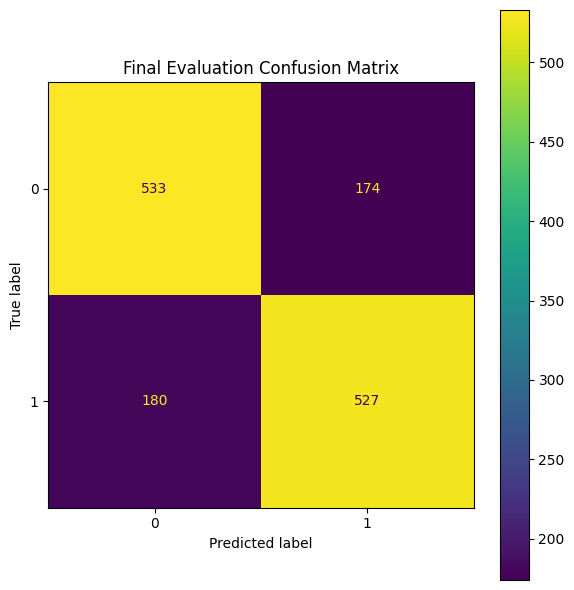

In [21]:
fig, ax = plt.subplots(
    figsize=(6, 6)
)

ConfusionMatrixDisplay.from_predictions(
    y_test_final,
    final_predictions,
    ax=ax,
    values_format="d"
)

ax.set_title(
    "Final Evaluation Confusion Matrix"
)

plt.tight_layout()
plt.show()


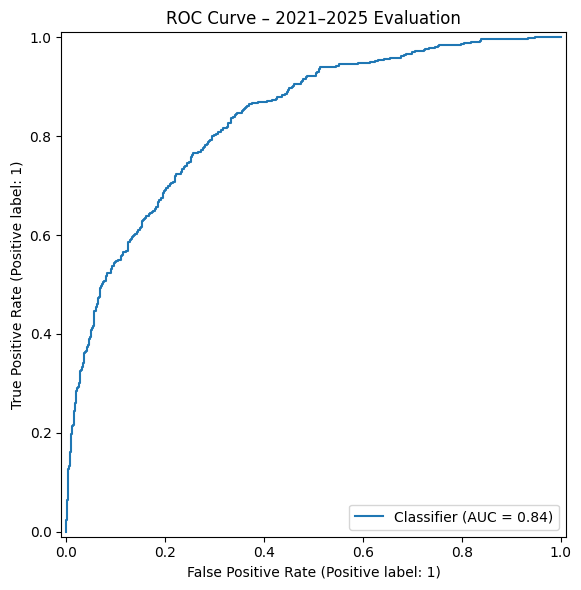

In [22]:
fig, ax = plt.subplots(
    figsize=(7, 6)
)

RocCurveDisplay.from_predictions(
    y_test_final,
    final_probabilities,
    ax=ax
)

ax.set_title(
    "ROC Curve – 2021–2025 Evaluation"
)

plt.tight_layout()
plt.show()


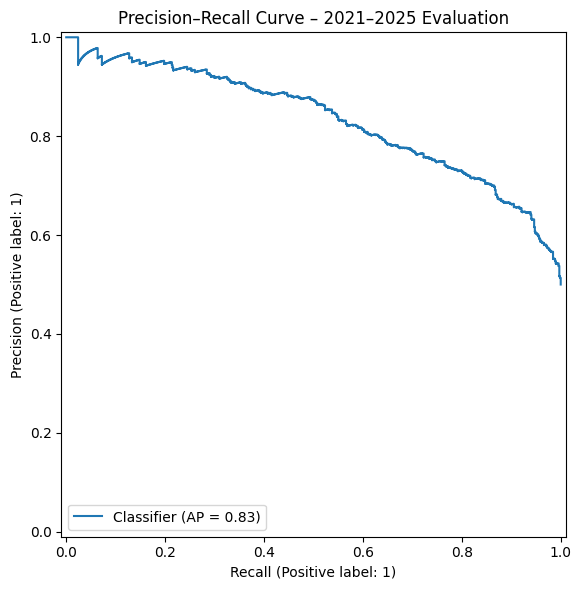

In [23]:
fig, ax = plt.subplots(
    figsize=(7, 6)
)

PrecisionRecallDisplay.from_predictions(
    y_test_final,
    final_probabilities,
    ax=ax
)

ax.set_title(
    "Precision–Recall Curve – 2021–2025 Evaluation"
)

plt.tight_layout()
plt.show()


### 16. Attach Prediction Scores


In [24]:
future_predictions_df = (
    final_features_df[
        [
            "actor_1",
            "actor_2",
            "label"
        ]
    ]
    .copy()
)

future_predictions_df[
    "prediction_score"
] = final_probabilities

future_predictions_df[
    "predicted_label"
] = final_predictions

future_predictions_df = (
    future_predictions_df
    .sort_values(
        "prediction_score",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

display(
    future_predictions_df
    .head(20)
)


,actor_1,actor_2,label,prediction_score,predicted_label
0,מוני מושונוב,צחי גראד,1,0.999987,1
1,אוהד קנולר,אורי גבריאל,1,0.999899,1
2,לבנה פינקלשטיין,ליאור אשכנזי,1,0.999876,1
3,צחי גראד,קרן מור,1,0.999850,1
4,ליאור אשכנזי,ששון גבאי,1,0.999694,1
5,אורי גבריאל,שמעון מימרן,1,0.999473,1
6,אוהד קנולר,אלברט אילוז,1,0.999233,1
7,אלברט אילוז,חיים זנאתי,1,0.999036,1
8,אלברט אילוז,ריימונד אמסלם,1,0.998895,1
9,חיים זנאתי,ריימונד אמסלם,1,0.998835,1


### 17. Add Future Movie Evidence

For realized future links, the first observed collaboration movie and year during 2021–2025 are attached to the prediction.


In [25]:
future_period_df = (
    edge_records_df[
        edge_records_df[
            "year"
        ].between(
            FINAL_FUTURE_START,
            FINAL_FUTURE_END
        )
    ]
    .copy()
)

future_period_df["edge"] = (
    future_period_df
    .apply(
        lambda row:
            canonical_edge(
                row["actor_1"],
                row["actor_2"]
            ),
        axis=1
    )
)

future_period_df = (
    future_period_df
    .sort_values(
        "year"
    )
    .drop_duplicates(
        subset="edge",
        keep="first"
    )
)

future_movie_lookup = {
    row.edge: {
        "movie_title":
            row.movie_title,
        "year":
            int(row.year)
    }
    for row
    in future_period_df
    .itertuples(
        index=False
    )
}


def add_future_movie_details(
    dataframe
):
    """Add the first observed future movie and year."""
    result = dataframe.copy()

    future_movies = []
    future_years = []

    for row in result.itertuples(
        index=False
    ):
        edge = canonical_edge(
            row.actor_1,
            row.actor_2
        )

        details = (
            future_movie_lookup
            .get(
                edge
            )
        )

        if details is not None:
            future_movies.append(
                details[
                    "movie_title"
                ]
            )

            future_years.append(
                details[
                    "year"
                ]
            )
        else:
            future_movies.append(
                ""
            )

            future_years.append(
                np.nan
            )

    result[
        "future_movie"
    ] = future_movies

    result[
        "future_year"
    ] = future_years

    return result


### 18. High-Score Predictions That Were Realized


In [26]:
realized_high_score_df = (
    future_predictions_df[
        future_predictions_df[
            "label"
        ].eq(1)
    ]
    .sort_values(
        "prediction_score",
        ascending=False
    )
    .head(30)
)

realized_high_score_df = (
    add_future_movie_details(
        realized_high_score_df
    )
)

display(
    realized_high_score_df
)


,actor_1,actor_2,label,prediction_score,predicted_label,future_movie,future_year
0,מוני מושונוב,צחי גראד,1,0.999987,1,חומוס FULL טריילר,2022
1,אוהד קנולר,אורי גבריאל,1,0.999899,1,מופע טוטאל,2025
2,לבנה פינקלשטיין,ליאור אשכנזי,1,0.999876,1,מזל חתולה,2024
3,צחי גראד,קרן מור,1,0.999850,1,חומוס FULL טריילר,2022
4,ליאור אשכנזי,ששון גבאי,1,0.999694,1,"קריוקי (סרט, 2022)",2022
5,אורי גבריאל,שמעון מימרן,1,0.999473,1,מופע טוטאל,2025
6,אוהד קנולר,אלברט אילוז,1,0.999233,1,מופע טוטאל,2025
7,אלברט אילוז,חיים זנאתי,1,0.999036,1,שער הפרחים (סרט),2022
8,אלברט אילוז,ריימונד אמסלם,1,0.998895,1,שער הפרחים (סרט),2022
9,חיים זנאתי,ריימונד אמסלם,1,0.998835,1,שער הפרחים (סרט),2022


### 19. High-Score Predictions That Were Not Realized

These actor pairs received high prediction scores but did not form an observed collaboration by the end of 2025.


In [27]:
unrealized_high_score_df = (
    future_predictions_df[
        future_predictions_df[
            "label"
        ].eq(0)
    ]
    .sort_values(
        "prediction_score",
        ascending=False
    )
    .head(30)
)

display(
    unrealized_high_score_df
)


,actor_1,actor_2,label,prediction_score,predicted_label
17,גל זייד,ליאור אשכנזי,0,0.996567,1
46,לבנה פינקלשטיין,משה פולקנפליק,0,0.978726,1
53,אורי גבריאל,ליאת גליק,0,0.975196,1
93,ריימונד אמסלם,שמואל שילה,0,0.951273,1
98,הוגו ירדן,יחזקאל לזרוב,0,0.949740,1
110,עידן טוקלומטי-ג'ורנו,שאדן קנבורה,0,0.939323,1
120,אורי קלאוזנר,מוטי בן ישי,0,0.931392,1
147,אביגיל הררי,אקי אבני,0,0.912959,1
159,לוסי דובינצ'יק,שרית וינו אלעד,0,0.900869,1
161,יואב בר לב,עידית טפרסון,0,0.899344,1


### 20. False-Negative Analysis


In [28]:
false_negative_df = (
    future_predictions_df[
        future_predictions_df[
            "label"
        ].eq(1)
        & future_predictions_df[
            "predicted_label"
        ].eq(0)
    ]
    .sort_values(
        "prediction_score",
        ascending=True
    )
)

false_negative_df = (
    add_future_movie_details(
        false_negative_df
    )
)

print(
    "False negatives:",
    len(false_negative_df)
)

display(
    false_negative_df
    .head(30)
)


False negatives: 180


,actor_1,actor_2,label,prediction_score,predicted_label,future_movie,future_year
1376,און רפאלי,חן אמסלם,1,0.062745,0,פול ספיד,2021
1365,לני כהן,ניב מג'ר,1,0.074179,0,ילד זין (סרט),2025
1310,און רפאלי,טל גרושקה,1,0.123002,0,פול ספיד,2021
1296,ליר כץ,תמיר גינזבורג,1,0.136314,0,כיסופים (סרט),2024
1295,אלעד צפני,ירון ברלד,1,0.136559,0,מרוסקים: גולסטאר הסרט,2024
1292,אדם גבאי,תמיר גינזבורג,1,0.140198,0,כיסופים (סרט),2024
1291,אליעד נחום,נועה קירל,1,0.140470,0,אוהב אותך צ'ארלי,2022
1278,יואל רוזנקיאר,רותם סלע,1,0.145813,0,סודה (סרט),2024
1267,אלישע בנאי,רמי פורטיס,1,0.148227,0,עצבני ומהיר: הסיפור של פאסט מיוזיק והפטיפון,2022
1262,יהונתן וילוז'ני,תמיר גינזבורג,1,0.149114,0,כיסופים (סרט),2024


In [29]:
false_negative_analysis_df = (
    final_features_df[
        [
            "actor_1",
            "actor_2",
            "common_neighbors",
            "jaccard",
            "adamic_adar",
            "preferential_attachment",
            "shortest_path",
            "same_community",
            "degree_sum",
            "pagerank_sum",
            "label"
        ]
    ]
    .merge(
        false_negative_df[
            [
                "actor_1",
                "actor_2",
                "prediction_score",
                "future_movie",
                "future_year"
            ]
        ],
        on=[
            "actor_1",
            "actor_2"
        ],
        how="inner"
    )
    .sort_values(
        "prediction_score",
        ascending=True
    )
)

display(
    false_negative_analysis_df
    .head(30)
)


,actor_1,actor_2,common_neighbors,jaccard,adamic_adar,preferential_attachment,shortest_path,same_community,degree_sum,pagerank_sum,label,prediction_score,future_movie,future_year
76,און רפאלי,חן אמסלם,0,0.000000,0.000000,54,5,0,15,0.000650,1,0.062745,פול ספיד,2021
86,לני כהן,ניב מג'ר,0,0.000000,0.000000,72,4,0,17,0.000635,1,0.074179,ילד זין (סרט),2025
91,און רפאלי,טל גרושקה,0,0.000000,0.000000,48,3,0,14,0.000605,1,0.123002,פול ספיד,2021
170,ליר כץ,תמיר גינזבורג,0,0.000000,0.000000,81,4,0,18,0.000595,1,0.136314,כיסופים (סרט),2024
125,אלעד צפני,ירון ברלד,0,0.000000,0.000000,72,4,0,17,0.000628,1,0.136559,מרוסקים: גולסטאר הסרט,2024
156,אדם גבאי,תמיר גינזבורג,0,0.000000,0.000000,72,4,0,17,0.000583,1,0.140198,כיסופים (סרט),2024
126,אליעד נחום,נועה קירל,0,0.000000,0.000000,81,4,0,18,0.000560,1,0.140470,אוהב אותך צ'ארלי,2022
134,יואל רוזנקיאר,רותם סלע,0,0.000000,0.000000,72,4,0,17,0.000614,1,0.145813,סודה (סרט),2024
43,אלישע בנאי,רמי פורטיס,0,0.000000,0.000000,81,4,0,18,0.000541,1,0.148227,עצבני ומהיר: הסיפור של פאסט מיוזיק והפטיפון,2022
123,יהונתן וילוז'ני,תמיר גינזבורג,0,0.000000,0.000000,63,4,0,16,0.000612,1,0.149114,כיסופים (סרט),2024


### 21. Cold-Start Analysis

Cold-start links contain at least one actor who was not present in the graph through 2020, so graph-only features could not be calculated for that actor pair.


In [30]:
cold_start_rows = []

for actor_1, actor_2 in sorted(
    final_cold_start_edges
):
    cold_start_rows.append({
        "actor_1":
            actor_1,
        "actor_2":
            actor_2,
        "actor_1_seen_before_2021":
            actor_1 in G_final,
        "actor_2_seen_before_2021":
            actor_2 in G_final
    })

cold_start_df = pd.DataFrame(
    cold_start_rows,
    columns=[
        "actor_1",
        "actor_2",
        "actor_1_seen_before_2021",
        "actor_2_seen_before_2021"
    ]
)

print(
    "Cold-start future links:",
    len(cold_start_df)
)

display(
    cold_start_df
    .head(30)
)


Cold-start future links: 1970


,actor_1,actor_2,actor_1_seen_before_2021,actor_2_seen_before_2021
0,אבא קובנר,אוגוסט דיהל,False,False
1,אבא קובנר,אמיתי קדר,False,False
2,אבא קובנר,יואל רוזנקיאר,False,True
3,אבא קובנר,ישי גולן,False,True
4,אבא קובנר,מיכאל אלוני,False,True
5,אבא קובנר,ניקולאי קינסקי,False,False
6,אבא קובנר,עוז זהבי,False,True
7,אבו עמר,אביתר אדרי,False,False
8,אבו עמר,אלברט אילוז,False,True
9,אבו עמר,ארקדי שוסטר,False,False


### 22. Feature Importance

Permutation Importance is used because it works consistently with all candidate classifiers, including HistGradientBoosting.

A larger positive value means that randomly shuffling the feature causes a larger decrease in ROC-AUC.


In [31]:
permutation_result = (
    permutation_importance(
        best_model,
        X_test_final,
        y_test_final,
        scoring="roc_auc",
        n_repeats=10,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
)

feature_importance_df = (
    pd.DataFrame({
        "feature":
            BEST_FEATURE_COLUMNS,
        "importance":
            permutation_result
            .importances_mean,
        "std":
            permutation_result
            .importances_std
    })
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

display(
    feature_importance_df
    .head(20)
)


,feature,importance,std
0,clustering_mean,0.157567,0.010113
1,pagerank_sum,0.064324,0.007880
2,preferential_attachment,0.062406,0.006920
3,shortest_path,0.054526,0.004802
4,spectral_l2,0.035102,0.001998
5,resource_allocation,0.021356,0.003168
6,weighted_degree_sum,0.016762,0.004268
7,common_neighbors,0.013763,0.003445
8,spectral_l1,0.011072,0.003381
9,degree_centrality_sum,0.009348,0.003577


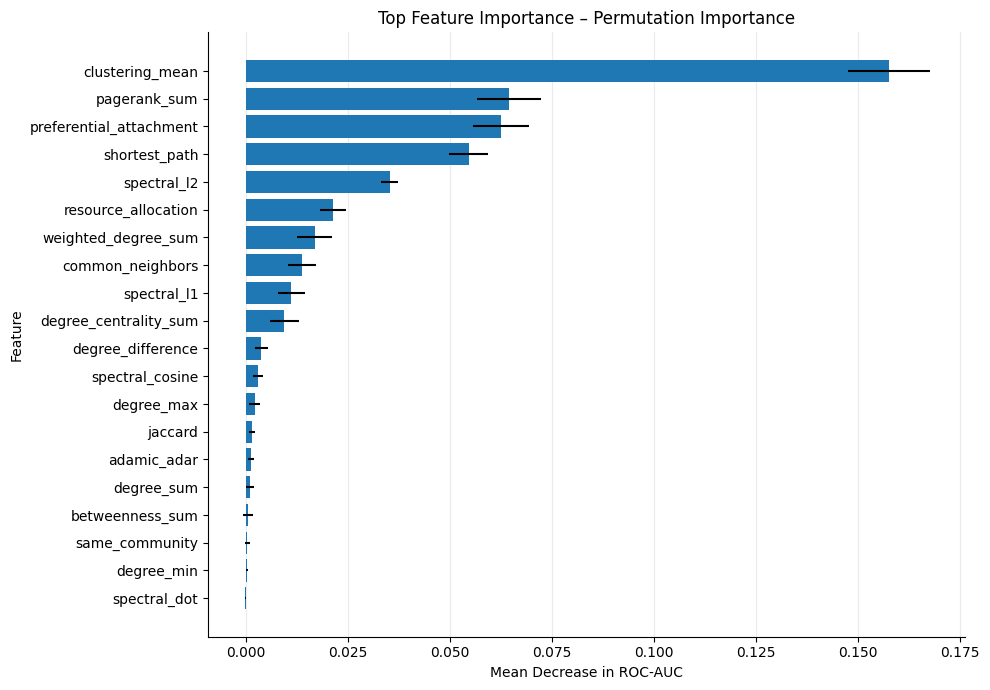

In [32]:
plot_df = (
    feature_importance_df
    .head(20)
    .sort_values(
        "importance",
        ascending=True
    )
)

fig, ax = plt.subplots(
    figsize=(10, 7)
)

ax.barh(
    plot_df["feature"],
    plot_df["importance"],
    xerr=plot_df["std"]
)

ax.set_title(
    "Top Feature Importance – Permutation Importance"
)

ax.set_xlabel(
    "Mean Decrease in ROC-AUC"
)

ax.set_ylabel(
    "Feature"
)

ax.spines[
    "top"
].set_visible(
    False
)

ax.spines[
    "right"
].set_visible(
    False
)

ax.grid(
    axis="x",
    alpha=0.25
)

ax.set_axisbelow(
    True
)

plt.tight_layout()
plt.show()


### 23. Prospective Link Predictions After 2025

The final requirement is to apply the selected approach to the full graph through 2025 and rank actor pairs that have not yet collaborated.

To keep the candidate space meaningful and computationally manageable, prospective candidates are restricted to non-edges whose actors share at least one common neighbor.


In [33]:
G_2025 = build_graph_for_years(
    movies_df,
    FULL_HISTORY_START,
    FULL_HISTORY_END
)

context_2025 = compute_graph_context(
    G_2025,
    seed=RANDOM_STATE + 3
)

latent_2025 = fit_latent_representations(
    G_2025,
    dimensions=16,
    seed=RANDOM_STATE + 3
)


def two_hop_candidate_edges(
    graph,
    max_candidates=50000
):
    """
    Generate plausible future non-edges.

    Each candidate pair shares at least one neighbor but
    has never collaborated directly through 2025.
    """
    common_neighbor_counts = {}

    for middle_actor in graph.nodes():
        neighbors = list(
            graph.neighbors(
                middle_actor
            )
        )

        for actor_1, actor_2 in combinations(
            neighbors,
            2
        ):
            if graph.has_edge(
                actor_1,
                actor_2
            ):
                continue

            edge = canonical_edge(
                actor_1,
                actor_2
            )

            common_neighbor_counts[
                edge
            ] = (
                common_neighbor_counts
                .get(
                    edge,
                    0
                )
                + 1
            )

    ranked_candidates = sorted(
        common_neighbor_counts,
        key=lambda edge: (
            -common_neighbor_counts[
                edge
            ],
            edge
        )
    )

    return ranked_candidates[
        :max_candidates
    ]


prospective_edges = (
    two_hop_candidate_edges(
        G_2025,
        max_candidates=50000
    )
)

print(
    "Full graph through 2025:"
)

print(
    "Nodes:",
    G_2025.number_of_nodes()
)

print(
    "Edges:",
    G_2025.number_of_edges()
)

print(
    "Prospective candidate non-edges:",
    len(prospective_edges)
)


Full graph through 2025:
Nodes: 2517
Edges: 19140
Prospective candidate non-edges: 50000


In [34]:
prospective_features_df = (
    create_feature_dataframe(
        G_2025,
        prospective_edges,
        [0]
        * len(
            prospective_edges
        ),
        context_2025,
        latent_2025
    )
)

post_2025_training_df = pd.concat(
    [
        train_features_df,
        validation_features_df,
        final_features_df
    ],
    ignore_index=True
)

post_2025_model = clone(
    MODELS[
        BEST_MODEL_NAME
    ]
)

post_2025_model.fit(
    post_2025_training_df[
        BEST_FEATURE_COLUMNS
    ].to_numpy(),
    post_2025_training_df[
        "label"
    ].to_numpy()
)

prospective_scores = (
    post_2025_model
    .predict_proba(
        prospective_features_df[
            BEST_FEATURE_COLUMNS
        ].to_numpy()
    )[:, 1]
)

prospective_predictions_df = (
    prospective_features_df[
        [
            "actor_1",
            "actor_2",
            "common_neighbors",
            "jaccard",
            "adamic_adar",
            "preferential_attachment",
            "shortest_path",
            "same_community"
        ]
    ]
    .copy()
)

prospective_predictions_df[
    "prediction_score"
] = prospective_scores

prospective_predictions_df = (
    prospective_predictions_df
    .sort_values(
        "prediction_score",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

display(
    prospective_predictions_df
    .head(30)
)


,actor_1,actor_2,common_neighbors,jaccard,adamic_adar,preferential_attachment,shortest_path,same_community,prediction_score
0,אורי גבריאל,אלון אבוטבול,31,0.112727,7.679221,23328,2,0,0.999994
1,אלון אבוטבול,ולדימיר פרידמן,24,0.094118,6.121386,18954,2,0,0.999986
2,ליאור אשכנזי,משה איבגי,23,0.080986,5.321496,23290,2,1,0.999985
3,עמוס לביא,צחי גראד,18,0.069498,4.516997,18720,2,0,0.999984
4,צחי גראד,שרון אלכסנדר,15,0.055970,3.604786,19680,2,0,0.999980
5,אסי דיין,צחי גראד,19,0.070370,4.550467,20640,2,0,0.999978
6,אלון אבוטבול,עמוס לביא,31,0.125000,7.878751,18954,2,0,0.999977
7,אלון אבוטבול,אסי דיין,26,0.098113,6.346292,20898,2,0,0.999975
8,דאנה איבגי,צחי גראד,18,0.070039,4.505267,18400,2,0,0.999970
9,ולדימיר פרידמן,משה איבגי,23,0.087121,5.615266,19890,2,0,0.999969


### 24. Conclusions


In [35]:
print(
    "Link Prediction Summary"
)

print(
    "-" * 35
)

print(
    "Selected feature set:",
    BEST_FEATURE_SET
)

print(
    "Selected model:",
    BEST_MODEL_NAME
)

print(
    "Validation ROC-AUC:",
    f"{best_row['ROC-AUC']:.4f}"
)

print(
    "Validation F1:",
    f"{best_row['F1']:.4f}"
)

print(
    "Final Precision:",
    f"{final_metrics['Precision']:.4f}"
)

print(
    "Final Recall:",
    f"{final_metrics['Recall']:.4f}"
)

print(
    "Final F1-score:",
    f"{final_metrics['F1']:.4f}"
)

print(
    "Final ROC-AUC:",
    f"{final_metrics['ROC-AUC']:.4f}"
)

print(
    "Final Average Precision:",
    f"{final_metrics['Average Precision']:.4f}"
)

print(
    "False negatives:",
    len(false_negative_df)
)

print(
    "Cold-start future links that could not be scored:",
    len(cold_start_df)
)

print(
    "Prospective post-2025 candidate links ranked:",
    len(prospective_predictions_df)
)


Link Prediction Summary
-----------------------------------
Selected feature set: Graph + Spectral
Selected model: Logistic Regression
Validation ROC-AUC: 0.8460
Validation F1: 0.7686
Final Precision: 0.7518
Final Recall: 0.7454
Final F1-score: 0.7486
Final ROC-AUC: 0.8351
Final Average Precision: 0.8334
False negatives: 180
Cold-start future links that could not be scored: 1970
Prospective post-2025 candidate links ranked: 50000


### 25. Limitations

- Graph-only models cannot retrospectively score collaborations involving actors who were absent from the corresponding historical snapshot.
- Wikipedia data may be incomplete or inconsistent.
- A high-score pair that did not collaborate through 2025 may still collaborate later.
- Negative examples are sampled because the complete set of non-edges is extremely large.
- Balanced evaluation sets are useful for model comparison but do not reproduce the naturally severe class imbalance of all possible actor pairs.
- Spectral embedding on a disconnected graph should be interpreted cautiously.
- Prospective predictions are restricted to two-hop non-edges with at least one common neighbor, so completely disconnected future collaborations are not ranked.
- Every graph feature and latent representation is recalculated from the appropriate historical snapshot to prevent temporal leakage.


### 26. Export Results


In [36]:
model_comparison_df.to_csv(
    "link_prediction_model_comparison.csv",
    index=False,
    encoding="utf-8-sig"
)

final_metrics_df.to_csv(
    "future_evaluation_metrics.csv",
    index=False,
    encoding="utf-8-sig"
)

future_predictions_df.to_csv(
    "future_test_predictions.csv",
    index=False,
    encoding="utf-8-sig"
)

realized_high_score_df.to_csv(
    "realized_high_score_predictions.csv",
    index=False,
    encoding="utf-8-sig"
)

unrealized_high_score_df.to_csv(
    "unrealized_high_score_predictions.csv",
    index=False,
    encoding="utf-8-sig"
)

false_negative_analysis_df.to_csv(
    "false_negative_analysis.csv",
    index=False,
    encoding="utf-8-sig"
)

cold_start_df.to_csv(
    "cold_start_links.csv",
    index=False,
    encoding="utf-8-sig"
)

feature_importance_df.to_csv(
    "feature_importance.csv",
    index=False,
    encoding="utf-8-sig"
)

prospective_predictions_df.to_csv(
    "prospective_link_predictions_after_2025.csv",
    index=False,
    encoding="utf-8-sig"
)

with open(
    "best_link_prediction_model.pkl",
    "wb"
) as file:
    pickle.dump(
        {
            "evaluation_model":
                best_model,
            "post_2025_model":
                post_2025_model,
            "feature_columns":
                BEST_FEATURE_COLUMNS,
            "feature_set":
                BEST_FEATURE_SET,
            "model_name":
                BEST_MODEL_NAME
        },
        file
    )

print(
    "Saved link-prediction analysis files."
)


Saved link-prediction analysis files.
